#### **Overview of Feature Engineering**

**Feature engineering** is the process of **transforming raw data into meaningful input variables** (features) that **improve the performance** of ML models. 

It is an important part of Machine Learning Pipeline
- **Pipeline** is a repeatable workflow that takes data from raw input to final results. 
- **Deployment** : Deployment in machine learning refers to the process of integrating a trained ML model into a real-world environment so that it can generate predictions on new, unseen data and deliver business value. In simple terms, deployment is the **step where a model moves from a notebook or experiment to actual usage**. This could be a local deployment or a cloud deployment. 

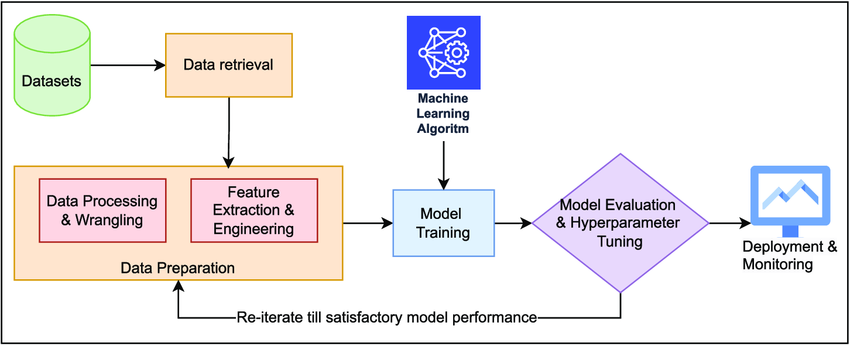

In [62]:
from IPython.display import Image, display
display(Image(filename="Typical-ML-pipeline-9.png"))

**Where Does Feature Engineering Sit in a Traditional ML Pipeline?**

1. Problem Definition
2. Data Collection
3. Data Understanding / EDA
4. Data Cleaning
5. Feature Engineering   ←––––––––––––––––– KEY STEP
6. Train–Test Split
7. Model Selection
8. Model Training
9. Model Evaluation
10. Hyperparameter Tuning
11. Model Deployment

**General Steps of Feature Engineering** (In no particular Order)

- Handle missing Values
- Handling Imbalanced Dataset
- Handling Outliers
- Feature Scaling
- Encoding
- Feature Selection
- Feature Transformation
- Feature Creation

### ETL : Extract transform load : Part of data engineering

In [63]:
# Regression : predict numbers (when data is of continuous type), eg House price prediction 
# Classification : predict Labels, categories : Pass/ fail prediction based on numbers 

## Practical

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [65]:
df=pd.read_csv('data/train.csv')
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [66]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [67]:
df.shape

(1460, 81)

### 1) Analysing missing data

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [69]:
missing_values=df.isnull().sum()
missing_values[missing_values>0].sort_values(ascending=False)
#type(missing_values)
## Shows only for numerical columns

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [70]:
#pip install missingno

In [71]:
import missingno as msno

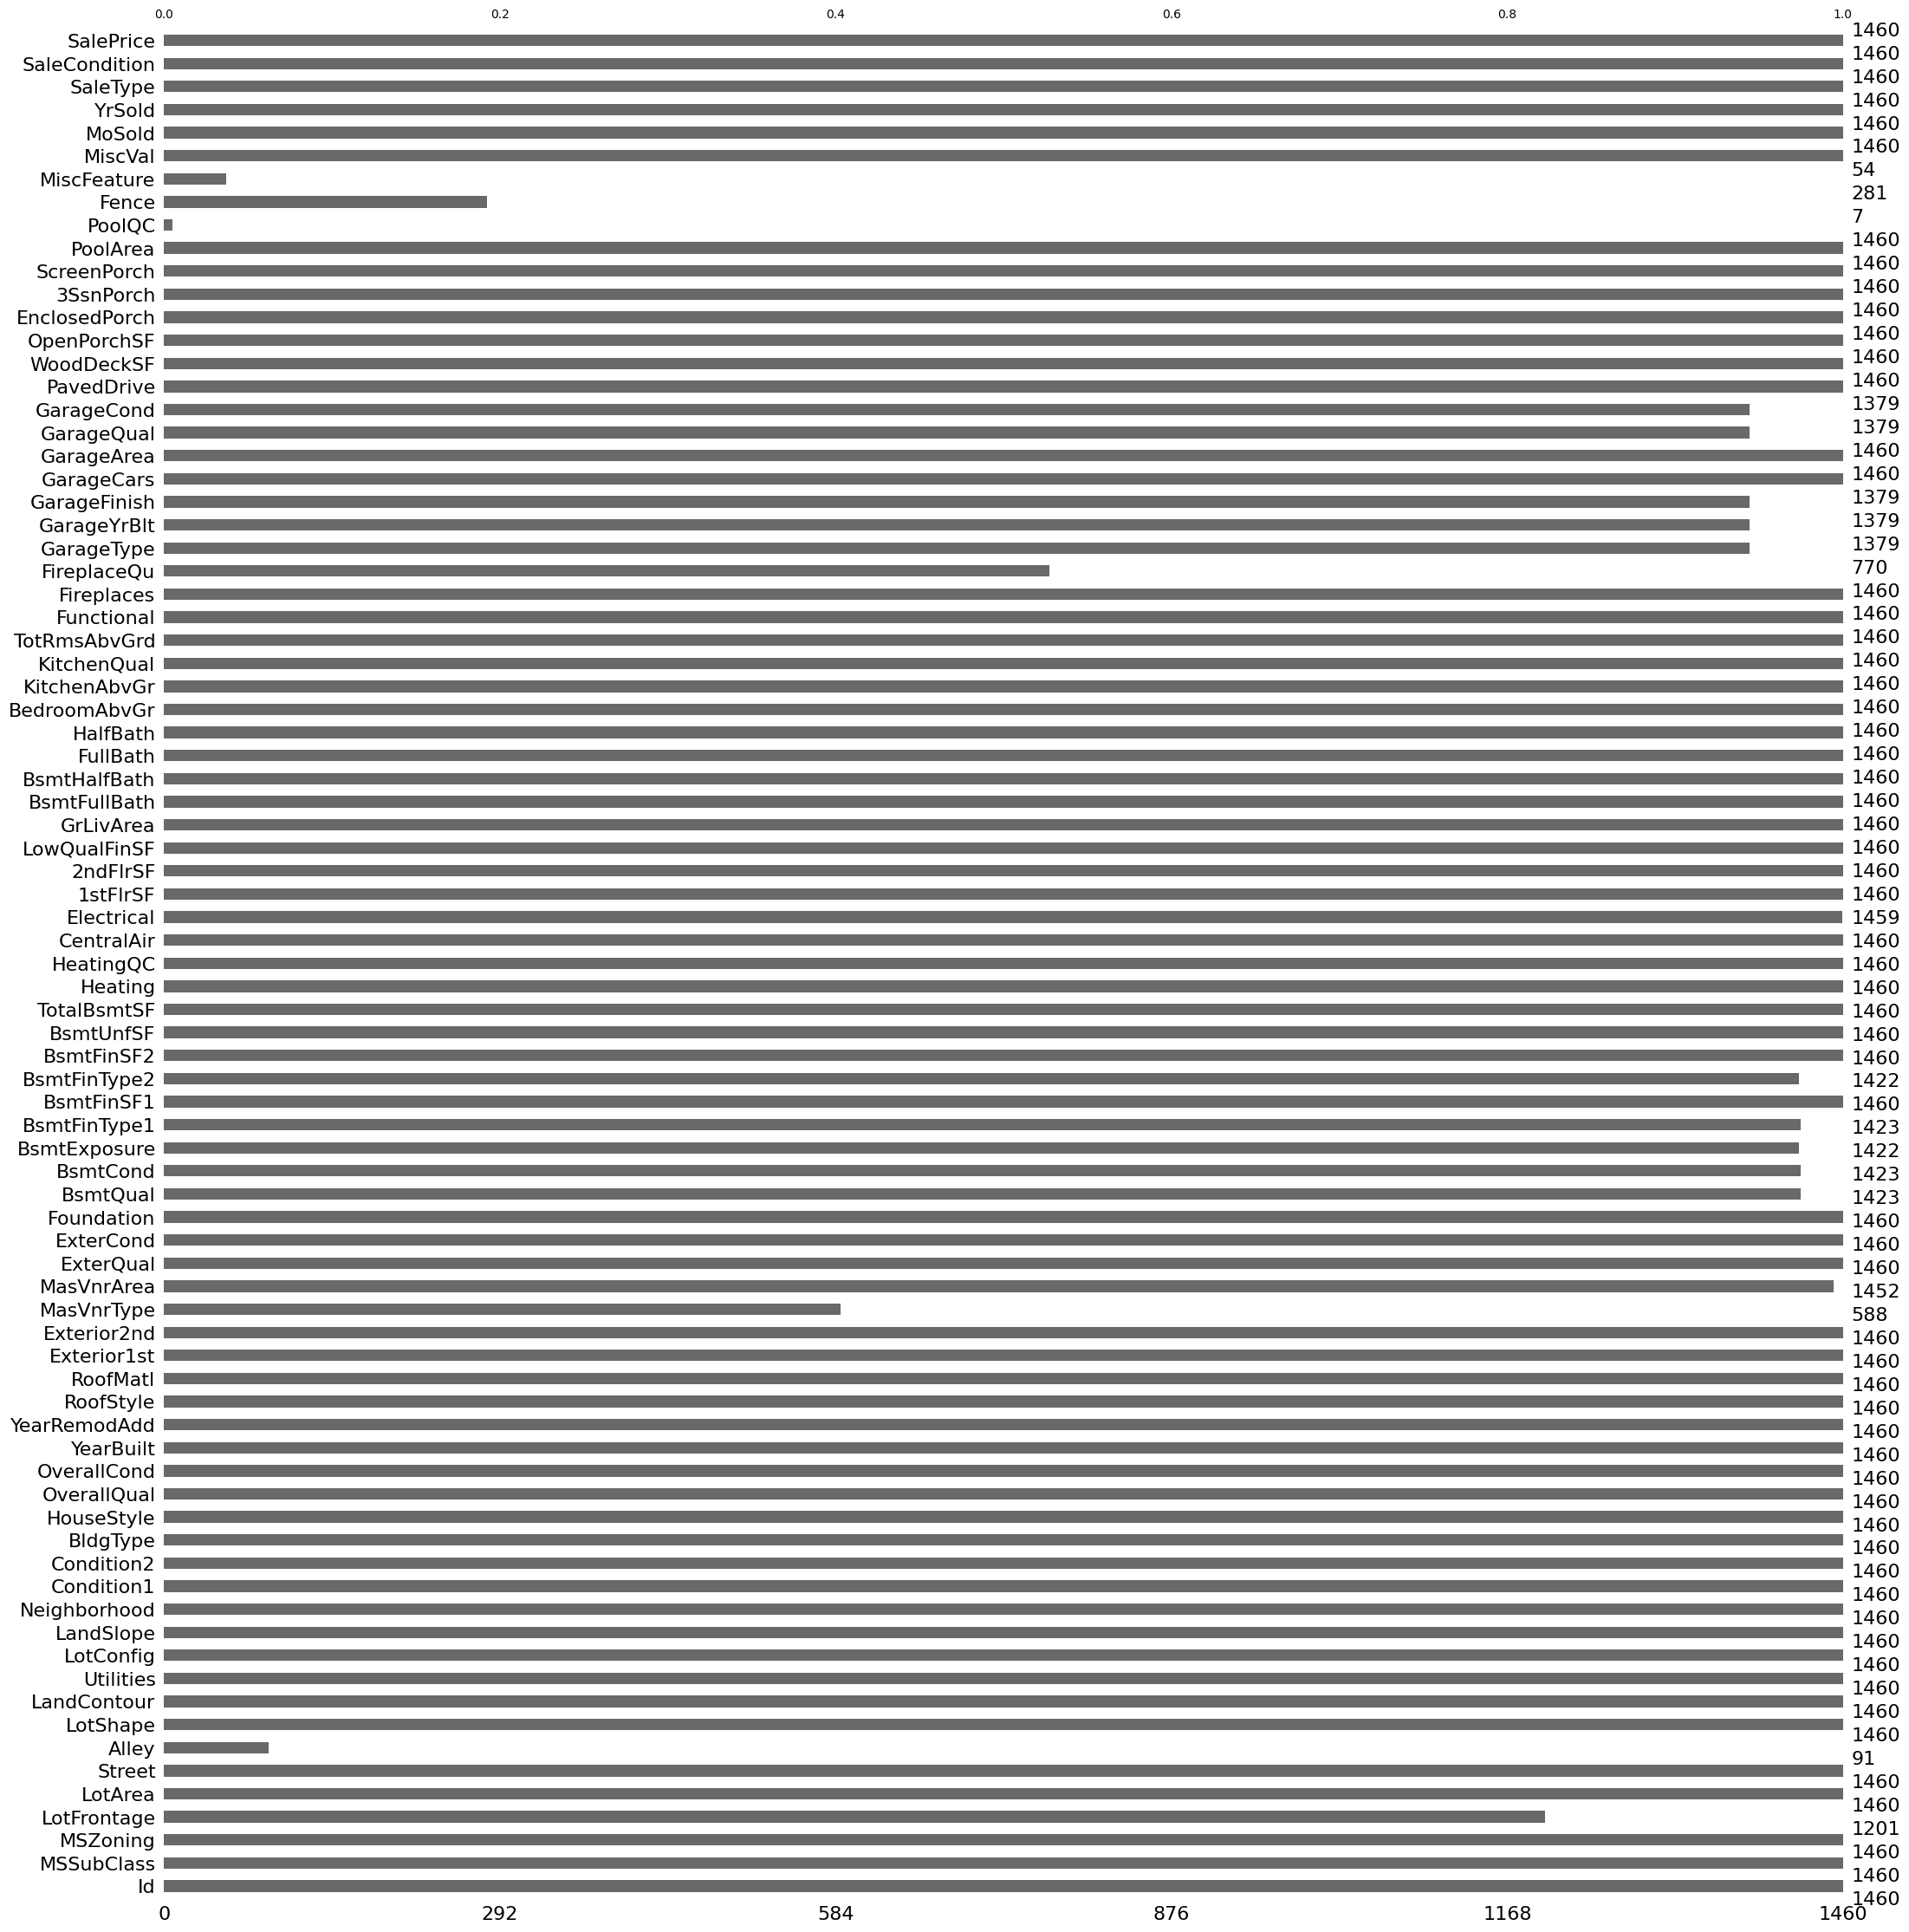

In [72]:
plt.figure(figsize=(12,6))
msno.bar(df)
plt.show()

In [73]:
# Gives details about all the columns and not just numeric columns
# Long bars means less missing values
# short bars means many missing values

### 2) Handling missing data

In [74]:
# There are 2 ways to handle missing values: delete or Impute
# - delete : 
# - impute

#### A) Deletion method : fails when a lot of missing values present 

In [75]:
df_listwise=df.dropna()
print('Original data frame shape was : ', df.shape)
print('Modified data frame shape was : ', df_listwise.shape)
# if any of my rows contain missing values, delete that row 
# Deletion should be used when most columns are stable and a few rows are unstable 

Original data frame shape was :  (1460, 81)
Modified data frame shape was :  (0, 81)


#### B) Simple Imputation method : Here we fill missing values with estimates, we do this column wise

#### B2) Mean imputation : done on numerical column 

In [76]:
df_mean=df.copy()
# here we are imputing LotFrontage where we wanna fill the missing values
#df_mean['LotFrontage'].fillna(df_mean['LotFrontage'].mean(), inplace=True)
df_mean.fillna({'LotFrontage': df_mean['LotFrontage'].mean()}, inplace=True)

In [77]:
# Function to check before and after of imputation

def compare_imputation(df_before, df_after, column_name):
    missing_indices = {column_name : df_before[df_before[column_name].isnull()].index.to_list() for column_name in df_before.columns if df_before[column_name].isnull().any()}

    if column_name not in missing_indices:
        print(f"No missing values were found in column '{column_name}'")
        return

    idx_list = missing_indices[column_name]

    comparison = pd.DataFrame({
        "Before" : df_before.loc[idx_list,column_name], 
        "After" : df_after.loc[idx_list,column_name], 
    })

    print(f"Changes in column : {column_name}")
    return comparison

In [78]:
compare_imputation(df, df_mean, "LotFrontage").head(10)

Changes in column : LotFrontage


,Before,After
7,NaN,70.049958
12,NaN,70.049958
14,NaN,70.049958
16,NaN,70.049958
24,NaN,70.049958
31,NaN,70.049958
42,NaN,70.049958
43,NaN,70.049958
50,NaN,70.049958
64,NaN,70.049958


In [79]:
## Cautious points with using mean :
# It will pull the distribution towards mean 
# underestimate the spread

#### B2) Median imputation : done on numerical column. Median ignores the mighty effect of outliers 

In [80]:
df_median = df.copy()
df_median.fillna({'LotFrontage': df_median['LotFrontage'].median()}, inplace=True)

In [81]:
compare_imputation(df, df_median, "LotFrontage").head(10)

Changes in column : LotFrontage


,Before,After
7,NaN,69.0
12,NaN,69.0
14,NaN,69.0
16,NaN,69.0
24,NaN,69.0
31,NaN,69.0
42,NaN,69.0
43,NaN,69.0
50,NaN,69.0
64,NaN,69.0


#### B3) Mode imputation : done on categorical column. For example : house - 90% of the house are in URBAN area, 10 % missing 

In [82]:
df_mode = df.copy()
df_mode.fillna({'GarageType': df_mode['GarageType'].mode()[0]}, inplace=True)

In [83]:
compare_imputation(df, df_mode, "GarageType").head(10)

Changes in column : GarageType


,Before,After
39,NaN,Attchd
48,NaN,Attchd
78,NaN,Attchd
88,NaN,Attchd
89,NaN,Attchd
99,NaN,Attchd
108,NaN,Attchd
125,NaN,Attchd
127,NaN,Attchd
140,NaN,Attchd


In [84]:
import seaborn as sns

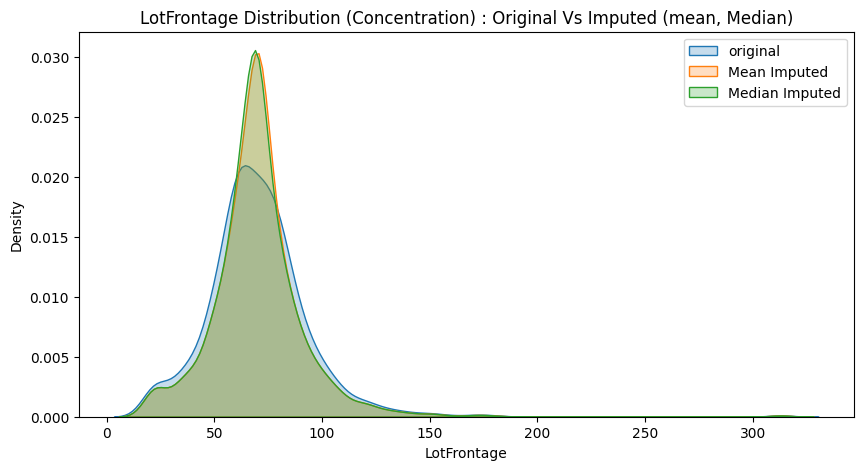

In [85]:
plt.figure(figsize=(10,5))
sns.kdeplot(df['LotFrontage'], label="original", fill=True)
sns.kdeplot(df_mean['LotFrontage'], label="Mean Imputed", fill=True)
sns.kdeplot(df_median['LotFrontage'], label="Median Imputed", fill=True)
plt.legend()
plt.title("LotFrontage Distribution (Concentration) : Original Vs Imputed (mean, Median)")
plt.show()

#### C) KNN imputation : MACHINE LEARNING METHOD 

In [86]:
#### when mean, mode, median imputation is used, all the null values will be imputed with the same value

In [88]:
from sklearn.impute import KNNImputer

In [89]:
knn_inputer = KNNImputer(n_neighbors=5)

In [90]:
df_knn = df.copy()
columns = ['LotFrontage', 'LotArea', 'YearBuilt']
df_knn[columns] = knn_inputer.fit_transform(df_knn[columns])

In [91]:
compare_imputation(df, df_knn, "LotFrontage").head(10)

Changes in column : LotFrontage


,Before,After
7,NaN,80.2
12,NaN,86.8
14,NaN,67.0
16,NaN,75.4
24,NaN,60.2
31,NaN,66.4
42,NaN,83.6
43,NaN,75.8
50,NaN,96.2
64,NaN,80.2


### **3) Handling Outliers**

An outlier is a data point that **deviates significantly from the majority of observations** in a dataset.
- Outlier distorts the mean towards itself.
- Outliers also represent rare and sometimes important cases 
- Some ML models like Linear Regression are very very sensitive to outliers. 

Steps to detect or handle outliers 
- Box plot (visualisation)
- IQR
- Z-score
- Winsorisation (Capping the extreme values)

#### 3.1) box plot 

In [92]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [93]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

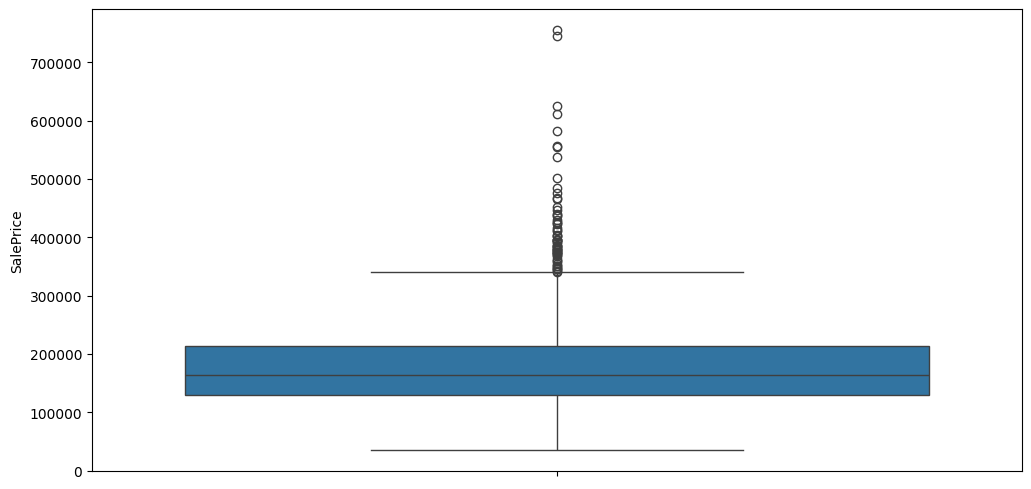

In [94]:
plt.figure(figsize=(12,6))
sns.boxplot(df['SalePrice'])
plt.show()

# left edge of blue box is lower Q1
# right edge of blue box is upper Q3
# Line between the blue box is median
# left whisker is = Q1 - 1.5*IQR
# right whisker is = Q3 + 1.5*IQR

##### **3.2) iqr**

In [95]:
import numpy as np 

In [96]:
def detect_outlier_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[col]>upper) | (data[col]<lower)]
    return outliers[[col]]

In [97]:
outliers_saleprice = detect_outlier_iqr(df, 'SalePrice')
len(outliers_saleprice)

61

In [98]:
outliers_saleprice

,SalePrice
11,345000
53,385000
58,438780
112,383970
151,372402
...,...
1268,381000
1353,410000
1373,466500
1388,377500


In [99]:
print(f'Minimum outlier:{outliers_saleprice.min()}')
print(f'Maximum outlier:{outliers_saleprice.max()}')
# outliers_saleprice.max()

Minimum outlier:SalePrice    341000
dtype: int64
Maximum outlier:SalePrice    755000
dtype: int64


##### **3.3) Z-score**

Z-score refers to a standardization (scaling) technique used to transform numerical features so that they are on a common scale.
- It indicates **how many standard deviations away** a value is from the feature's **mean value**

- A |Z score| > 3 --> commonly treated as outlier. 
    - For a normally distributed data :
        - 68% of a 2 tailed data lies within 1 SD
        - 95% of a 2 tailed data lies within 2 SD
        - 99.7% of a 2 tailed data lies within 3 SD

- Use Z-score for outlier detection when the data is :
    - approximately normally distributed (Gaussian)
    - Dataset is moderate to large say > 50 rows. 
    - You need high explainability

In [100]:
from scipy.stats import zscore

In [101]:
df['SalePriceZScore']= zscore(df['SalePrice'])
outliers_z = df[df['SalePriceZScore'].abs()>3]

len(outliers_z)

22

##### **Qplot (probplot) can be used to check if the data is normally distributed**

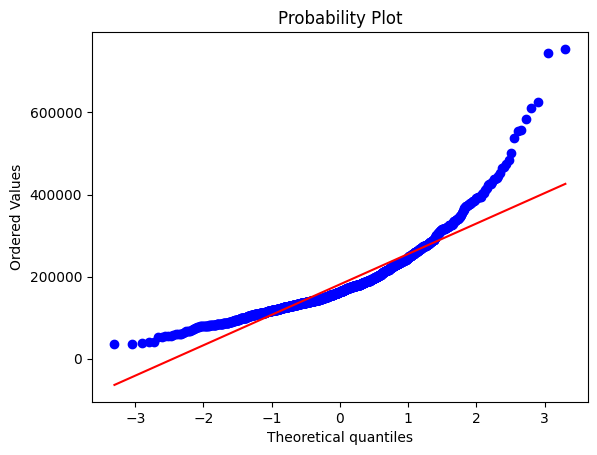

In [ ]:
import scipy.stats as stats
stats.probplot(df['SalePrice'], dist='norm', plot=plt)
plt.show()


## Had the data been normal the blue line would have followed the diagonal red line